# Image Compression using SVD (Singular Value Decomposition)

This code demonstrates image compression using SVD by creating low-rank approximations
of a grayscale image. It shows both visual results at different compression levels
and analyzes the importance of singular values in representing the image.

The compression works by keeping only the r most significant singular values and their
corresponding singular vectors, where r is the truncation rank. Lower r means higher
compression but potentially lower image quality.

## Methods
-------
1. Convert RGB image to grayscale
2. Perform SVD decomposition
3. Create compressed versions using different truncation ranks
4. Analyze singular value distribution and cumulative importance

Original image shape: (5001, 3334, 3)


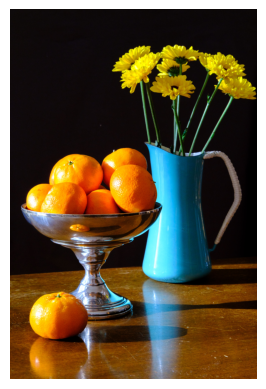

In [10]:
from matplotlib.image import imread
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = imread("StillLife.jpg")
print(f"Original image shape: {image.shape}")
plt.axis('off')
plt.imshow(image)
plt.show()


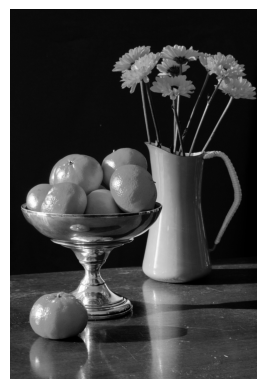

In [6]:
# Convert image to grayscale
image_grayscale = np.mean(image, axis=-1)  # Average RGB channels
plt.imshow(image_grayscale, cmap='gray')
plt.axis('off')
plt.show()

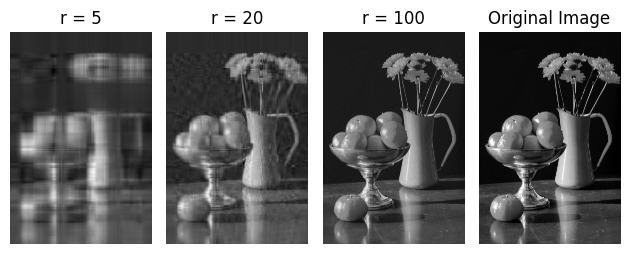

In [7]:
# Perform SVD decomposition
U, S, Vt = np.linalg.svd(image_grayscale, full_matrices=False)
S = np.diag(S)  # Convert singular values to diagonal matrix

# Create and display compressed versions
fig, ax = plt.subplots(nrows=1, ncols=4) # Create 4 subplots 

for i, r in enumerate([5, 20, 100]):  # Different compression levels
   compressed_image = U[:,:r] @ S[:r, :r] @ Vt[:r, :]  # Create rank-r approximation
   ax[i].imshow(compressed_image, cmap="grey")
   ax[i].set_title(f"r = {r}")
   ax[i].axis("off")

# Display original image for comparison
ax[-1].imshow(image_grayscale, cmap="grey")
ax[-1].set_title("Original Image")
ax[-1].axis("off")
plt.tight_layout() # Adjust layout for better visualization
plt.show()

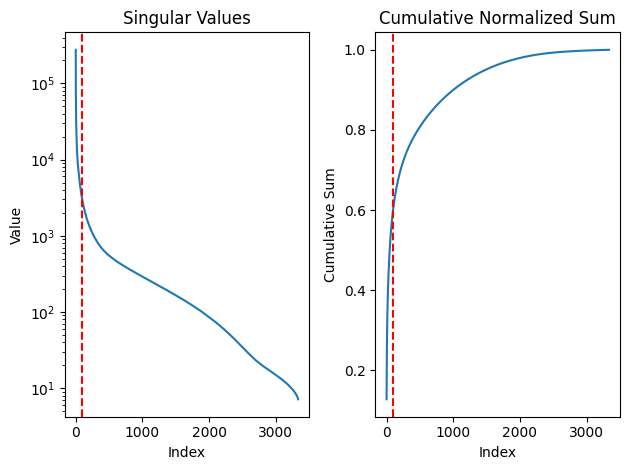

In [15]:
# Analyze singular values
fig, ax = plt.subplots(nrows=1, ncols=2) #create 2 subplots

ax[0].set_title("Singular Values")
ax[0].semilogy(np.diag(S))  # Plot singular values with a y log scale
ax[0].set_xlabel("Index")
ax[0].set_ylabel("Value")
ax[0].axvline(100,  color='red', linestyle='--')  # Mark r=100 for reference

ax[1].set_title("Cumulative Normalized Sum")
ax[1].plot(np.cumsum(np.diag(S))/np.sum(np.diag(S)))  # Show cumulative importance
ax[1].set_xlabel("Index")
ax[1].set_ylabel("Cumulative Sum")
ax[1].axvline(100, color='red', linestyle='--')  # Mark r=100 for reference
plt.tight_layout()
plt.show()